## 1. Preparación del Entorno

### 1.1 Instalación de dependencias y descarga del dataset

In [4]:
%pip install tensorflow

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import numpy as np
import os, shutil, math
from PIL import Image
import matplotlib.pyplot as plt


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.3/351.2 MB 7.4 MB/s eta 0:00:48
   ---------------------------------------- 3.1/351.2 MB 7.7 MB/s eta 0:00:46
    --------------------------------------- 4.5/351.2 MB 7.5 MB/s eta 0:00:47
    --------------------------------------- 6.3/351.2 MB 7.7 MB/s eta 0:00:45
    --------------------------------------- 7.6/351.2 MB 7.7 MB/s eta 0:00:45
   - -------------------------------------- 9.2/351.2 MB 7.6 MB/s eta 0:00:45
   - -------------------------------------- 10.7/351.2 MB 7.6 MB/s eta 0:00:46
   - -------------------------------------- 12.3/351.2 MB 7.5 MB/s eta 0:00:46
   - -------------------------------------- 13.9/351.2 MB 7.5 MB/s eta 0:00:45
   - -------------------------------------- 15.5/351.2 MB 7.6 MB/s eta 0:00:44
   - -------------------------------------- 17.3/351.2 MB 7.6 MB/s eta 0:00:4

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl (351.2 MB)
Note: you may need to restart the kernel to use updated packages.


In [7]:
RUTA_DATA = r'C:\Users\jacob\OneDrive - UFV\IA 2\Talleres\Taller 3 CNN\Data'
# Detectar clases desde las subcarpetas
clases = sorted([c for c in os.listdir(RUTA_DATA)
                 if os.path.isdir(os.path.join(RUTA_DATA, c))])

In [ ]:
print(f"{'Clases':<12} {'Imágenes por clase':>10}")
conteos = {}
for clase in clases:
    n = len(os.listdir(os.path.join(RUTA_DATA, clase)))
    conteos[clase] = n

total = sum(conteos.values())
for clase, n in conteos.items():
    print(f"{clase:<12} {n:>10}   {n/total*100:>5.1f}%")

print(f"{'TOTAL':<12} {total:>10}")

#Miro el tamaño de una imagen de ejemplo para saber a qué tamaño redimensionar después
primera_clase = clases[0]
primer_archivo = os.listdir(os.path.join(RUTA_DATA, primera_clase))[0]
img_muestra = Image.open(os.path.join(RUTA_DATA, primera_clase, primer_archivo))
print(f"\nTamaño de imagen: {img_muestra.size}")

Clases       Imágenes por clase
Angry             10148    17.2%
Fear               9732    16.5%
Happy             18439    31.2%
Sad               12553    21.2%
Suprise            8227    13.9%
TOTAL             59099

Tamaño de imagen: (48, 48)


Muestro un ejemplo de 5 imagenes por clase 

C:\Users\jacob\AppData\Local\Temp\ipykernel_7360\1898941504.py:23: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jacob\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


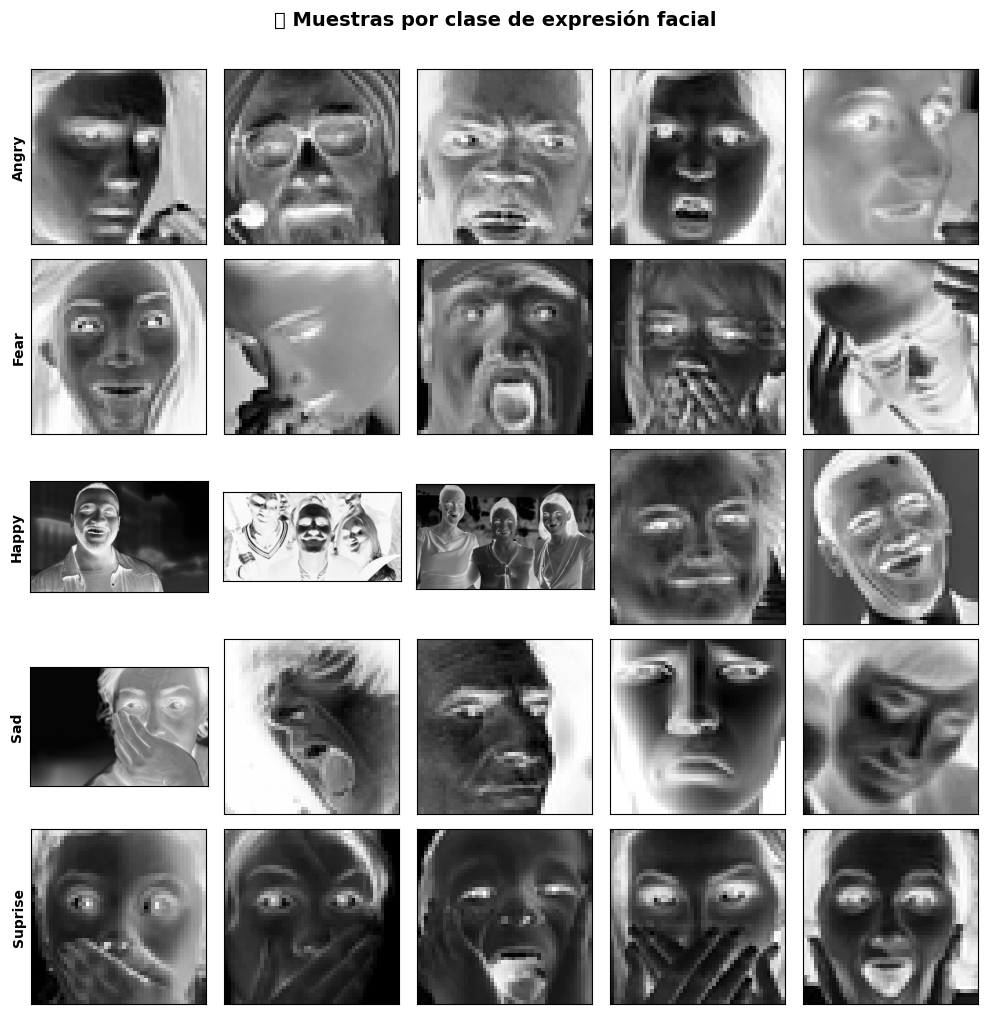

In [ ]:
MUESTRAS_POR_CLASE = 5

fig, axes = plt.subplots(len(clases), MUESTRAS_POR_CLASE, figsize=(MUESTRAS_POR_CLASE * 2, len(clases) * 2))

for fila, clase in enumerate(clases):
    carpeta = os.path.join(RUTA_DATA, clase)
    archivos = os.listdir(carpeta)[:MUESTRAS_POR_CLASE]

    for col, archivo in enumerate(archivos):
        img = Image.open(os.path.join(carpeta, archivo)).convert('L')
        ax = axes[fila, col]
        ax.imshow(np.array(img), cmap=plt.cm.binary)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        if col == 0:
            ax.set_ylabel(clase, fontsize=10, fontweight='bold')

plt.suptitle('Muestras por clase de expresión facial', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Creo el Split de train y validacion p

In [ ]:
# Proporciones 70 / 15 / 15
PROP_TRAIN = 0.70
PROP_VAL   = 0.15

RUTA_SPLIT = os.path.join(os.path.dirname(RUTA_DATA), 'Data_split')
RUTA_TRAIN = os.path.join(RUTA_SPLIT, 'train')
RUTA_VAL   = os.path.join(RUTA_SPLIT, 'val')
RUTA_TEST  = os.path.join(RUTA_SPLIT, 'test')

if os.path.exists(RUTA_SPLIT):
    print("⚠️  Data_split/ ya existe, no se repite la copia.")
else:
    np.random.seed(42)

    for clase in clases:
        archivos = np.array(os.listdir(os.path.join(RUTA_DATA, clase)))
        np.random.shuffle(archivos)

        n_total = len(archivos)
        n_train = int(n_total * PROP_TRAIN)
        n_val   = int(n_total * PROP_VAL)

        splits = {
            'train': archivos[:n_train],
            'val'  : archivos[n_train : n_train + n_val],
            'test' : archivos[n_train + n_val:]
        }

        for split_nombre, split_archivos in splits.items():
            destino = os.path.join(RUTA_SPLIT, split_nombre, clase)
            os.makedirs(destino, exist_ok=True)
            for archivo in split_archivos:
                shutil.copy(
                    os.path.join(RUTA_DATA, clase, archivo),
                    os.path.join(destino, archivo)
                )

    print("✅ Data_split/ creada")

# Verificar conteos
print(f"\n{'Clase':<12} {'Train':>7} {'Val':>7} {'Test':>7}")
print("-" * 35)
for clase in clases:
    n_tr = len(os.listdir(os.path.join(RUTA_TRAIN, clase)))
    n_va = len(os.listdir(os.path.join(RUTA_VAL,   clase)))
    n_te = len(os.listdir(os.path.join(RUTA_TEST,  clase)))
    print(f"{clase:<12} {n_tr:>7} {n_va:>7} {n_te:>7}")